In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pprint

CALLS_PARQUET = "harmonized_calls_2021_2026.parquet"

In [2]:
df = pd.read_parquet(CALLS_PARQUET, engine='fastparquet')

In [3]:
df['hour'] = df['event_time'].dt.hour
df['date'] = df['event_time'].dt.date
df['day_of_week'] = df['event_time'].dt.dayofweek
df['month'] = df['event_time'].dt.month
df['year'] = (df['event_time'].dt.year).astype(int)
df['response_time'] = (df['arrival_time'] - df['event_time']).dt.total_seconds() / 60
df['travel_time'] = (df['arrival_time'] - df['dispatch_time']).dt.total_seconds() / 60
df['priority'] = df['priority'].astype(float).astype(int)

df.head()
# print(len(df)) # 2276366

,agency,event_number,address,beat,call_source,priority,event_time,dispatch_time,arrival_time,incident_type_code,...,disposition_code,disposition_text,source_sheet,hour,date,day_of_week,month,year,response_time,travel_time
0,OP,LOP210101000001,E 15TH ST&35TH AV,23X,911 CALL,2,2021-01-01 00:00:43,2021-01-01 11:36:56,2021-01-01 11:49:11,415GS,...,None,UNABLE TO LOCATE,2021,0,2021-01-01,4,1,2021,708.466667,12.250000
1,OP,LOP210101000002,E 23RD ST&FRUITVALE AV,21Y,DEFAULT - PHONE INIT,2,2021-01-01 00:00:51,2021-01-01 00:59:23,2021-01-01 01:00:33,415GS,...,None,GONE ON ARRIVAL,2021,0,2021-01-01,4,1,2021,59.700000,1.166667
2,OP,LOP210101000003,6929 FOOTHILL BLVD,30Y,911 CALL,2,2021-01-01 00:00:54,NaT,NaT,415FC,...,None,CANCELLED,2021,0,2021-01-01,4,1,2021,NaN,NaN
3,OP,LOP210101000004,104TH AV&WALNUT ST,32X,DEFAULT - PHONE INIT,2,2021-01-01 00:01:02,2021-01-01 00:39:31,2021-01-01 00:40:58,415GS,...,None,UNABLE TO LOCATE,2021,0,2021-01-01,4,1,2021,39.933333,1.450000
4,OP,LOP210101000005,1564 76TH AV,30X,911 CALL,2,2021-01-01 00:01:24,NaT,NaT,415C,...,None,CANCELLED,2021,0,2021-01-01,4,1,2021,NaN,NaN


In [4]:
p1 = df[df['priority'] == 1].copy()
p1.head()
# print(len(p1)) # 415327

,agency,event_number,address,beat,call_source,priority,event_time,dispatch_time,arrival_time,incident_type_code,...,disposition_code,disposition_text,source_sheet,hour,date,day_of_week,month,year,response_time,travel_time
15,OP,LOP210101000016,8500 G ST,33X,911 CALL,1,2021-01-01 00:03:50,2021-01-01 00:04:47,2021-01-01 00:08:43,245,...,None,TEC REQUEST HANDLED,2021,0,2021-01-01,4,1,2021,4.883333,3.933333
21,OP,LOP210101000022,17TH AV&SAN ANTONIO WY,18X,911 CALL,1,2021-01-01 00:06:25,2021-01-01 00:07:30,2021-01-01 00:09:28,CODE7,...,None,GONE ON ARRIVAL,2021,0,2021-01-01,4,1,2021,3.050000,1.966667
22,OP,LOP210101000023,2541 SEMINARY AV,29X,911 CALL,1,2021-01-01 00:07:01,2021-01-01 00:41:07,NaT,415GS,...,None,REPORT TAKEN-ASSIGNMENT REPORT,2021,0,2021-01-01,4,1,2021,NaN,NaN
25,OP,LOP210101000026,8100 MACARTHUR BLVD,30Y,911 CALL,1,2021-01-01 00:07:20,2021-01-01 07:39:16,2021-01-01 07:41:46,CODE7,...,None,COVER,2021,0,2021-01-01,4,1,2021,454.433333,2.500000
29,OP,LOP210101000030,12TH ST&MANDELA PKWY,02Y,DEFAULT - PHONE INIT,1,2021-01-01 00:08:42,2021-01-01 00:16:41,2021-01-01 00:28:11,245,...,None,GONE ON ARRIVAL,2021,0,2021-01-01,4,1,2021,19.483333,11.500000


In [6]:
# Stats
var = 'travel_time' # or 'response_time'
data = df # or 'p1'

response_time_stats = (
    data.groupby('year')[var]
    .agg(
        counts='count',
        medians='median',
        means='mean',
        mins='min',
        maxes='max',
        zeroes=lambda x: (x == 0).mean(),
        two_hour_plus=lambda x: (x > 120).mean(),
    )
    .reset_index()
    .rename(columns={'year': 'years'})
)

print(response_time_stats.to_string(index=False, float_format='%.2f'))

 years  counts  medians  means      mins     maxes  zeroes  two_hour_plus
  2021  206973     3.77  22.71  -1426.12  54851.55    0.19           0.01
  2022  198984     3.58  22.79      0.00  97456.27    0.20           0.01
  2023  167039     0.00  27.53      0.00  47381.50    0.22           0.01
  2024  179918     3.14  24.69 -11342.81 142553.69    0.14           0.01
  2025  109219     7.99  32.12  -9851.46  61778.68    0.00           0.01
  2026   53050     8.24  38.26  -2475.20  10594.45    0.00           0.01


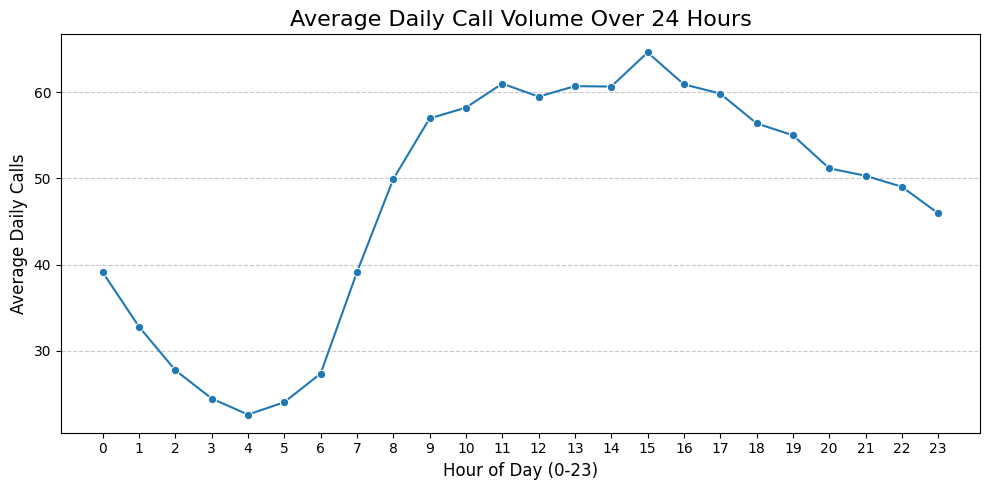

In [7]:
# 1. Count calls per specific day and hour
hourly_daily_counts = (
    df.groupby(['date', 'hour']).size().reset_index(name='call_count')
)

# 2. Calculate the mean daily volume for each hour across all days
hourly_vol_avg = (
    hourly_daily_counts.groupby('hour')['call_count']
    .mean()
    .reset_index(name='avg_call_volume')
)

# Plot average hourly volume
plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_vol_avg, x='hour', y='avg_call_volume', marker='o')

plt.title('Average Daily Call Volume Over 24 Hours', fontsize=16)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Average Daily Calls', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("daily_call_volume.png", dpi=150, bbox_inches="tight")

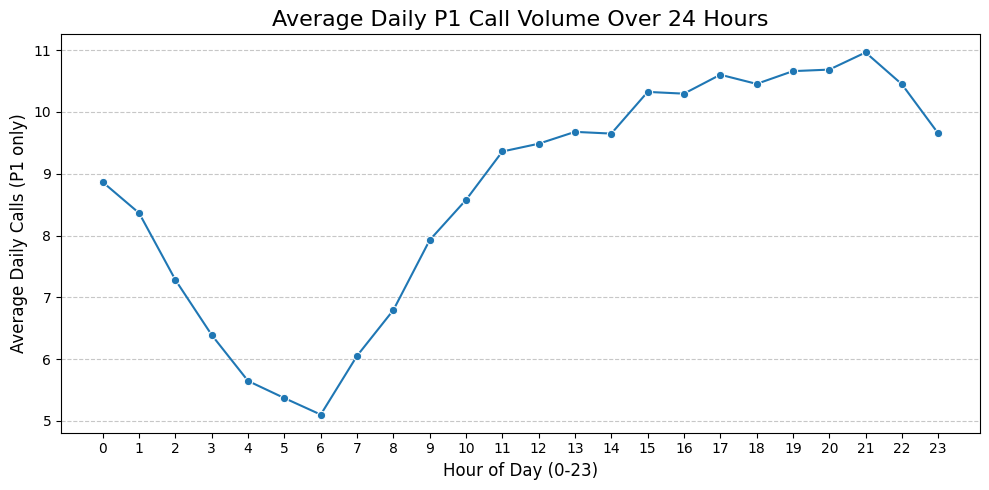

In [8]:
# 1. Count calls per specific day and hour
hourly_daily_counts = (
    p1.groupby(['date', 'hour']).size().reset_index(name='call_count')
)

# 2. Calculate the mean daily volume for each hour across all days
hourly_vol_avg = (
    hourly_daily_counts.groupby('hour')['call_count']
    .mean()
    .reset_index(name='avg_call_volume')
)

# Plot average hourly volume
plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_vol_avg, x='hour', y='avg_call_volume', marker='o')

plt.title('Average Daily P1 Call Volume Over 24 Hours', fontsize=16)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Average Daily Calls (P1 only)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("p1_daily_call_volume.png", dpi=150, bbox_inches="tight")

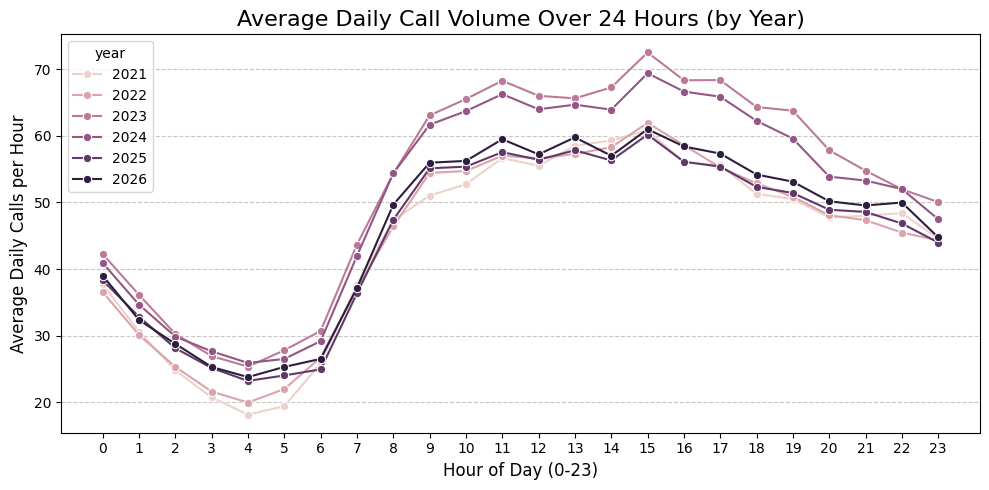

In [9]:
# 1. Count calls per specific date, year, and hour
hourly_daily_counts = (
    df.groupby(['year', 'date', 'hour']).size().reset_index(name='call_count')
)

# 2. Calculate average daily call volume for each hour, split by year
hourly_vol_annual_avg = (
    hourly_daily_counts.groupby(['year', 'hour'])['call_count']
    .mean()
    .reset_index(name='avg_call_volume')
)

# Plot average hourly volume by year
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=hourly_vol_annual_avg,
    x='hour',
    y='avg_call_volume',
    hue='year',
    marker='o',
)

plt.title('Average Daily Call Volume Over 24 Hours (by Year)', fontsize=16)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Average Daily Calls per Hour', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("daily_call_volume_annual.png", dpi=150, bbox_inches="tight")
plt.show()

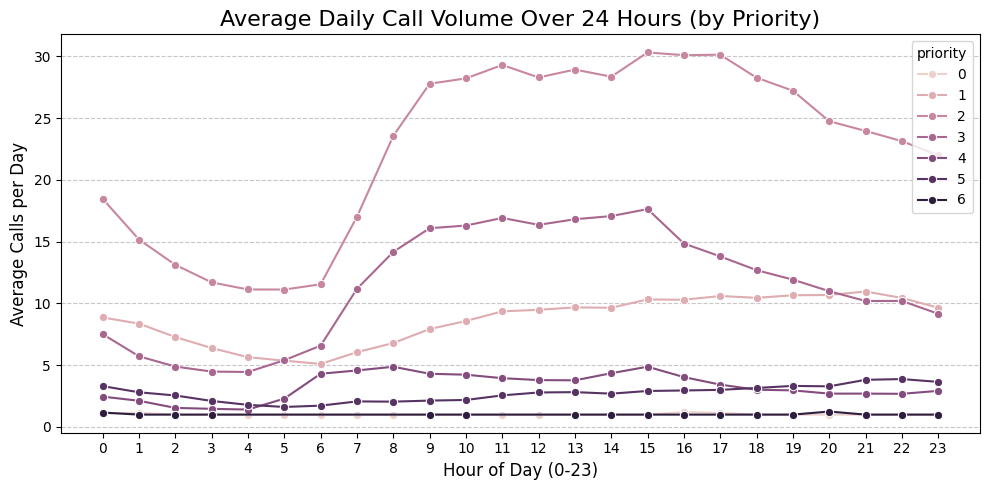

In [10]:
# 1. Count calls per specific date, priority, and hour
hourly_daily_counts = (
    df.groupby(['priority', 'date', 'hour']).size().reset_index(name='call_count')
)

# 2. Calculate average daily call volume for each hour, split by priority
hourly_vol_prioritized_avg = (
    hourly_daily_counts.groupby(['priority', 'hour'])['call_count']
    .mean()
    .reset_index(name='avg_call_volume')
)

# Plot average hourly volume by priority
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=hourly_vol_prioritized_avg,
    x='hour',
    y='avg_call_volume',
    hue='priority',
    marker='o',
)

plt.title('Average Daily Call Volume Over 24 Hours (by Priority)', fontsize=16)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Average Calls per Day', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('daily_call_volume_by_priority.png', dpi=150, bbox_inches='tight')
plt.show()

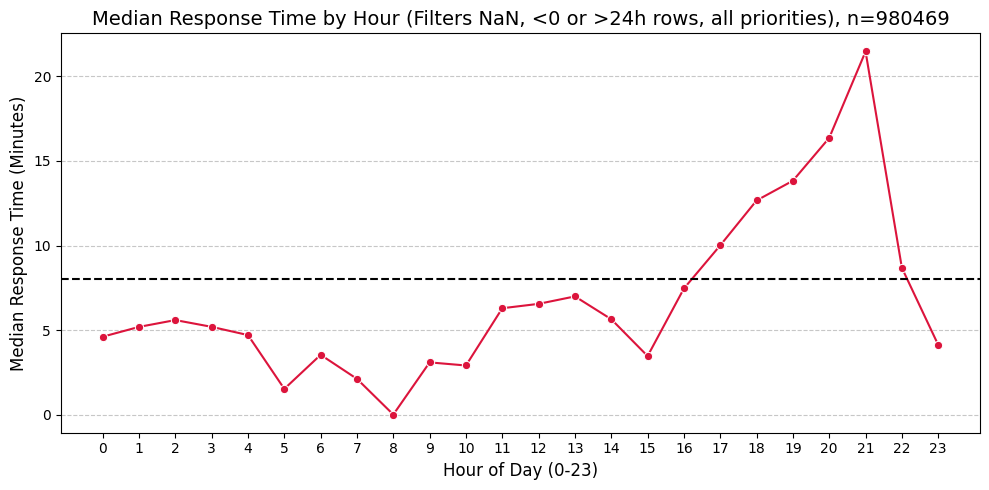

In [21]:
# Filter df table to remove NaN, <0, or >1440 response times

df_clean = df[  
    (df['response_time'].notna()) & 
    (df['response_time'] >= 0) &
    (df['response_time'] <= 1440)
    ].copy()

n = df_clean.shape[0]

# Calculate median response time by hour
df_hourly = (
    df_clean.groupby('hour')['response_time']
    .median()
    .reset_index(name='median_response_time')
)

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_hourly,
    x='hour',
    y='median_response_time',
    marker='o',
    color='crimson',
)
plt.axhline(y=8, color='black', linestyle='--', linewidth=1.5, label='8 Min SLA')

plt.title('Median Response Time by Hour (Filters NaN, <0 or >24h rows, all priorities), n=' + str(n), fontsize=14)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Median Response Time (Minutes)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("median_response_time_filtered.png", dpi=150, bbox_inches="tight")

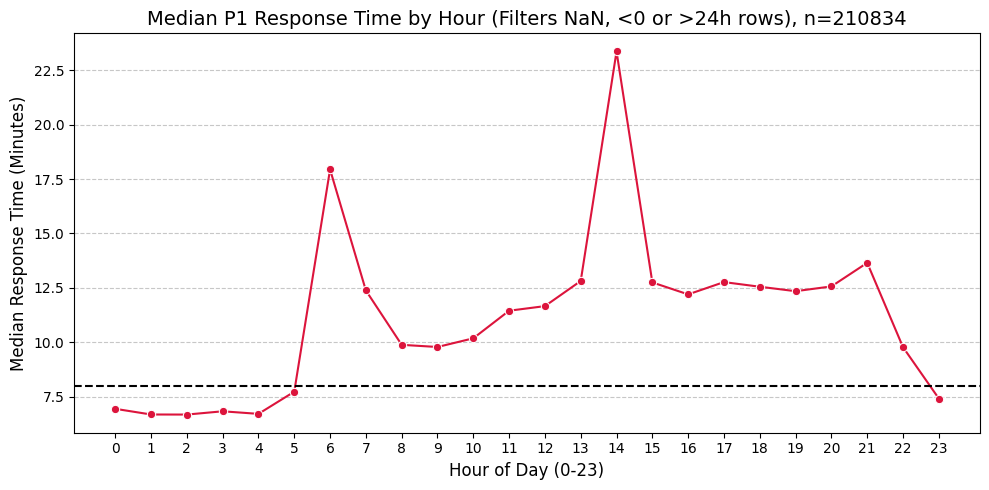

In [20]:
# Filter p1 table to remove NaN, <0, or >1440 response times

p1_clean = p1[  
    (p1['response_time'].notna()) & 
    (p1['response_time'] >= 0) &
    (p1['response_time'] <= 1440)
    ].copy()

n = p1_clean.shape[0]

# Calculate median response time by hour
p1_hourly = (
    p1_clean.groupby('hour')['response_time']
    .median()
    .reset_index(name='median_response_time')
)

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=p1_hourly,
    x='hour',
    y='median_response_time',
    marker='o',
    color='crimson',
)
plt.axhline(y=8, color='black', linestyle='--', linewidth=1.5, label='8 Min SLA')

plt.title('Median P1 Response Time by Hour (Filters NaN, <0 or >24h rows), n=' + str(n), fontsize=14)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Median Response Time (Minutes)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("p1_median_response_time_filtered.png", dpi=150, bbox_inches="tight")

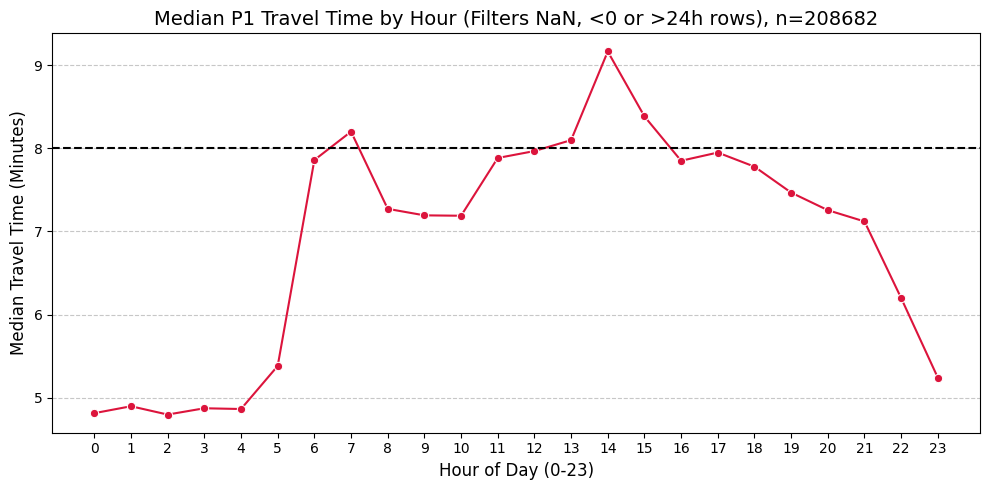

In [18]:
# Filter p1 table to remove NaN, <0, or >1440 travel times

p1_clean = p1[  
    (p1['travel_time'].notna()) & 
    (p1['travel_time'] >= 0) &
    (p1['travel_time'] <= 1440)
    ].copy()

n = p1_clean.shape[0]

# Calculate median travel time by hour
p1_hourly = (
    p1_clean.groupby('hour')['travel_time']
    .median()
    .reset_index(name='median_travel_time')
)

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=p1_hourly,
    x='hour',
    y='median_travel_time',
    marker='o',
    color='crimson',
)
plt.axhline(y=8, color='black', linestyle='--', linewidth=1.5, label='8 Min SLA')

plt.title('Median P1 Travel Time by Hour (Filters NaN, <0 or >24h rows), n=' + str(n), fontsize=14)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Median Travel Time (Minutes)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("p1_travel_response_time_filtered.png", dpi=150, bbox_inches="tight")

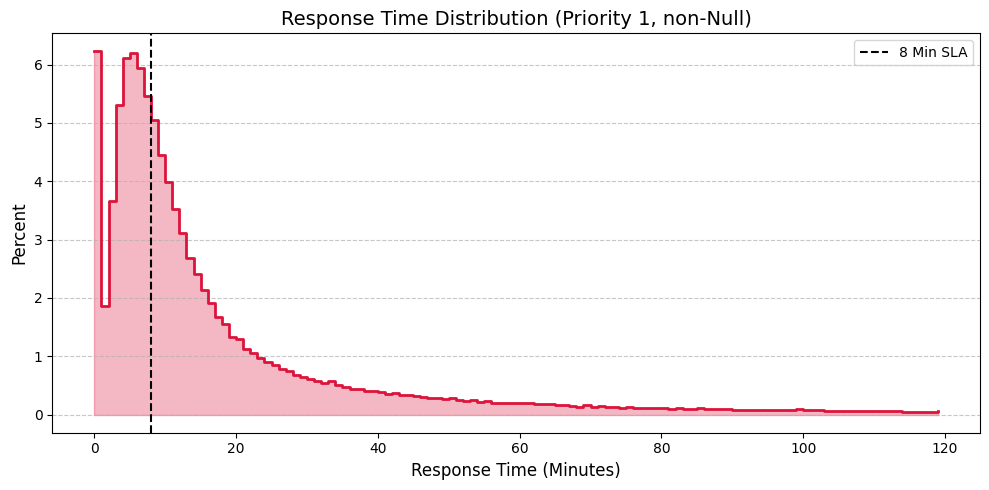

In [22]:
# 1. Compute 1-minute bins using NumPy C-extension (takes milliseconds)
max_min = 120
bins = np.arange(0, max_min + 1, 1)  # Bins: [0, 1, 2, ..., 60]
counts, bin_edges = np.histogram(p1['response_time'], bins=bins)
pcts = (counts / counts.sum()) * 100

# 2. Plot step outline (extremely fast rendering)
plt.figure(figsize=(10, 5))
plt.step(bin_edges[:-1], pcts, where='post', color='crimson', linewidth=2)
plt.fill_between(bin_edges[:-1], pcts, step='post', color='crimson', alpha=0.3)

plt.axvline(x=8, color='black', linestyle='--', linewidth=1.5, label='8 Min SLA')
plt.title('Response Time Distribution (Priority 1, non-Null)', fontsize=14)
plt.xlabel('Response Time (Minutes)', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("p1_response_time_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Priority 1 calls by Beat
p1_beat = p1_clean.copy()
beat_median_response = p1_beat.groupby('beat')['response_time_min'].median().reset_index(name='median_response_time_min')
beat_volume = p1_beat.groupby('beat').size().reset_index(name='call_volume')

In [ ]:
# Plot priority 1 call volume by beat

plt.figure(figsize=(12, 6))
sns.barplot(
    data=beat_volume,
    x='beat',
    y='call_volume'
)

plt.title('Call Volume by Beat (Priority 1, Non-Null)', fontsize=14)
plt.xlabel('Beat', fontsize=12)
plt.ylabel('Call Volume', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotates location labels if text is long
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.savefig("../Outputs/p1_volume_by_beat.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Plot priority 1 median response time by beat

plt.figure(figsize=(12, 6))
sns.barplot(
    data=beat_median_response,
    x='beat',
    y='median_response_time_min'
)

# Add horizontal 8-minute SLA line if needed
plt.axhline(y=8, color='black', linestyle='--', label='8 Min SLA')

plt.title('Median Response Time by Beat (Priority 1, Non-Null)', fontsize=14)
plt.xlabel('Beat', fontsize=12)
plt.ylabel('Median Response Time (minutes)', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotates location labels if text is long
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.savefig("../Outputs/p1_median_response_time_by_beat.png", dpi=150, bbox_inches="tight")
plt.show()